# Data cleaning

**Lavigne Nancy**

I am working with the Titanic dataset to clean, process, and analyze passenger profiles so I can prepare structural features for machine learning model training.


### Step 1: Initializing my data science workspace
I am importing **Pandas** to construct and manipulate my data tables, **NumPy** to support complex mathematical vector operations, and **Matplotlib** so I can design clean visual plots and charts later in my analysis.


In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Ingesting the raw dataset
I am reading the raw Titanic passenger data directly from the tested.csv storage file and parsing it into a structured memory structure named df_titanic so I can analyze it using Python.


In [133]:
df_titanic=pd.read_csv('tested.csv')

### Step 3: Performing a preliminary structural audit
I am displaying the first 5 records of my DataFrame to conduct a quick visual evaluation of the features, looking closely at how passenger attributes like age, gender, passenger class, and cabin tracking are stored.


In [134]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Step 4: Diagnosing data types and missing fields
I am running a comprehensive structural summary of my data table to evaluate the entry count, determine the exact data formats of each feature, and map out exactly where empty cells exist across my columns.


In [135]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


### Step 5: Filling missing ages for passengers with the title Master
I am finding all passengers whose names contain the title **Master**, calculating their specific average age, and using that average to fill in any of their missing age values.


In [136]:
mask= df_titanic["Name"].str.contains("Master", na=False)
master_age_mean = df_titanic.loc[mask,"Age"].mean()
df_titanic.loc[mask,"Age"] = df_titanic.loc[mask,"Age"].fillna(master_age_mean)

### Step 6: Filling missing ages for passengers with the title Mister
I am filtering for passengers with **Mister** in their name, finding their average age, and using it to fill their missing age values so that their data is imputed more accurately than using a global average.


In [137]:
mask = df_titanic["Name"].str.contains("Mister", na=False)
mister_age_mean = df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask, "Age"]= df_titanic.loc[mask, "Age"].fillna(mister_age_mean)

### Step 7: Calculating the average age for passengers with the title Miss
I am creating a filter to find every passenger with the title **Miss** in their name. I am then calculating the average age of this specific group to fill in any missing age values with a more relevant mean.


In [138]:
mask = df_titanic["Name"].str.contains("Miss", na=False)
miss_age_mean = df_titanic.loc[mask, "Age"].mean()
print("The average age for passengers with the title Miss is:", miss_age_mean)
df_titanic.loc[mask, "Age"] = df_titanic.loc[mask, "Age"].fillna(miss_age_mean)


The average age for passengers with the title Miss is: 21.774843750000002


### Step 8: Manually correcting missing embarkation ports using biographical data
I am using known historical records from the Mrs. George Nelson Stone Biography Page to locate her record using a string mask and manually assigning her correct port of embarkation, which is Southampton (S). Link: [Mrs. George Nelson Stone Biography Page](https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html)


In [139]:
mask = df_titanic["Name"].str.contains("Stone, Mrs. George Nelson", na=False)
df_titanic.loc[mask, "Embarked"] = "S"


### Step 9: Dropping target and unnecessary columns
I am creating my feature matrix X by dropping the Survived target column and the Cabin column from the original dataset.


In [140]:
X=df_titanic.drop(['Survived','Cabin'],axis =1)


### Step 10: Isolating the target column for prediction
I am extracting only the *Survived* column and saving it as my target label variable Y so I can train my classification model to predict this specific outcome later.


In [141]:
Y=df_titanic['Survived']

### Step 11: Previewing the structural features matrix
I am displaying the first 5 records of my processed training feature dataset X to verify that the Survived labels and the highly incomplete Cabin values were cleanly dropped.


In [142]:
X.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


### Step 12: Auditing target label integrity
I am printing out the first 5 records of my target label dataset Y to confirm it contains exactly the expected binary outputs representing survival results.


In [143]:
Y.head(5)

0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64

### Step 13: Visualizing target class distribution
I am calculating the value counts for my target categories and plotting them as a bar chart to see if my dataset is balanced or heavily skewed toward one outcome.


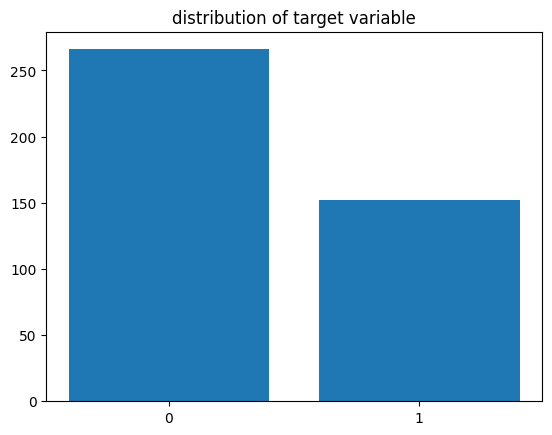

In [144]:
x=Y.value_counts()
plt.bar(x.index,x)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()

### Step 14: Initializing categorical encoder tools
I am importing LabelEncoder from scikit-learn so I can prepare to convert my categorical text data columns into numbers that my machine learning model can process.


In [145]:
from sklearn.preprocessing import LabelEncoder

### Step 15: Converting text categories to numbers
I am creating a new DataFrame called *train*. This will help me loop through every column in X where it contains text, then I convert the words into numeric codes, and if it already contains numbers, I keep them exactly as they are.


In [146]:
train = pd.DataFrame()
label = LabelEncoder()

for c in X.columns:
    if X[c].dtype == 'object':
        train[c] = label.fit_transform(X[c])
    else:
        train[c] = X[c]




### Step 16: Verifying my new clean numeric dataset
I am checking the first 5 rows of my new train DataFrame to make sure that text columns like Name, Sex, and Ticket have successfully turned into numerical values.


In [147]:
train.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,206,1,34.5,0,0,152,7.8292,1
1,893,3,403,0,47.0,1,0,221,7.0000,2
2,894,2,269,1,62.0,0,0,73,9.6875,1
3,895,3,408,1,27.0,0,0,147,8.6625,2
4,896,3,178,0,22.0,1,1,138,12.2875,2


### Step 17: Removing high-cardinality ID columns to prevent overfitting
I am dropping PassengerId, Name, and Ticket from my numeric dataset because unique text tracking values cause the model to memorize the exact rows instead of learning useful generalized rules.


In [148]:
X_final = train.drop(columns=['PassengerId', 'Name', 'Ticket'], errors='ignore')


### Step 18: Bringing in my machine learning tools
I am importing the tools I need to split my data into training and testing sets, build a Logistic Regression model, evaluate its accuracy, and set up cross-validation strategies.


In [149]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

### Step 19: Defining my model training function
I am creating a reusable function called logistic. It will split the data into 80% training and 20% testing sets, train a Logistic Regression model on the training data, make predictions, and print the overall accuracy score.


In [150]:
def logistic(X, Y):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, test_size=0.2)
    lr = LogisticRegression(max_iter=500)
    lr.fit(X_train, Y_train)
    Y_pre = lr.predict(X_test)
    print('Accuracy: ', accuracy_score(Y_test, Y_pre))


### Step 20: Checking for any leftover missing values
I am calculating the sum of missing values for each column to locate exactly which features still have blank cells before training my model.


In [151]:
train.isnull().sum()


PassengerId     0
Pclass          0
Name            0
Sex             0
Age            68
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
dtype: int64

### Step 21: Imputing all remaining missing numbers with column means
I am automatically filling the remaining missing values across my entire dataset using the average of each column to ensure there are no blank fields left to break the model.


In [152]:
train = train.fillna(train.mean())


### Step 22: Running the baseline classification model
I am passing my features and target labels into my custom function to train the Logistic Regression model and output its initial accuracy score.


In [155]:
logistic(train, Y)


Accuracy:  1.0


/home/student/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# One-Hot Encoding and Model Evaluation Issues

## 1. Verification of Columns
I am importing OneHotEncoder from scikit-learn so I can convert my categorical text columns into separate binary columns (0s and 1s) without creating an artificial numerical hierarchy.


In [156]:
from sklearn.preprocessing import OneHotEncoder

### Step 23: Transforming text features into binary columns
I am applying the one-hot encoder to the **Sex** and **Embarked** columns, converting them into brand new binary tracking columns, and merging them back into my main dataset while dropping the original text columns.

In [157]:
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(train[['Sex', 'Embarked']])
encoded_df = pd.DataFrame(
    encoded_features, 
    columns=encoder.get_feature_names_out(['Sex', 'Embarked'])
)
train = train.drop(columns=['Sex', 'Embarked']).join(encoded_df)
train.head()


,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_0,Sex_1,Embarked_0,Embarked_1,Embarked_2
0,892,3,206,34.5,0,0,152,7.8292,0.0,1.0,0.0,1.0,0.0
1,893,3,403,47.0,1,0,221,7.0000,1.0,0.0,0.0,0.0,1.0
2,894,2,269,62.0,0,0,73,9.6875,0.0,1.0,0.0,1.0,0.0
3,895,3,408,27.0,0,0,147,8.6625,0.0,1.0,0.0,0.0,1.0
4,896,3,178,22.0,1,1,138,12.2875,1.0,0.0,0.0,0.0,1.0


### Step 24: Defining the optimized evaluation function
I am creating a clean, reusable function to split my incoming data into training and testing splits, fit the updated Logistic Regression classifier using an increased iteration cap of 500, and print the resulting accuracy score.


In [158]:
def logistic(X, Y):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, test_size=0.2)
    lr = LogisticRegression(max_iter=500)
    lr.fit(X_train, Y_train)
    Y_pre = lr.predict(X_test)
    print('Accuracy: ', accuracy_score(Y_test, Y_pre))


### Step 25: Removing high-cardinality metadata columns to prevent overfitting
I am dropping PassengerId, Name, and Ticket from my transformed dataset because unique text identifiers cause the model to memorize the rows rather than learn useful rules.


In [159]:
X_final = train.drop(columns=['PassengerId', 'Name', 'Ticket'], errors='ignore')


### Step 26: Evaluating my model's performance
I am passing my final cleaned feature matrix X_final and target variable Y into my optimized evaluation function to split the data, train the Logistic Regression model, and print out the accuracy score.


In [160]:
logistic(X_final, Y)


Accuracy:  1.0
